In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
dataset = pd.read_csv("car data (1).csv")
print(dataset.head(3))

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  


In [3]:
print("\nDataset Shape:")
print(dataset.shape)

print("\nDataset Info:")
print(dataset.info())

print("\nMissing Values:")
print(dataset.isnull().sum())


Dataset Shape:
(301, 9)

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [5]:
current_year = 2026
dataset['Car_Age'] = current_year - dataset['Year']

In [6]:
dataset.drop(['Car_Name', 'Year'], axis=1, inplace=True)

In [9]:
le = LabelEncoder()

dataset['Fuel_Type'] = le.fit_transform(dataset['Fuel_Type'])
dataset['Selling_type'] = le.fit_transform(dataset['Selling_type'])
dataset['Transmission'] = le.fit_transform(dataset['Transmission'])

In [10]:
X = dataset.drop('Selling_Price', axis=1)
y = dataset['Selling_Price']

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [13]:
model = LinearRegression()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

In [14]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)


Model Performance:
MAE : 1.221932362175385
MSE : 3.531579888968638
RMSE: 1.8792498207978199
R2 Score: 0.8466902419663827


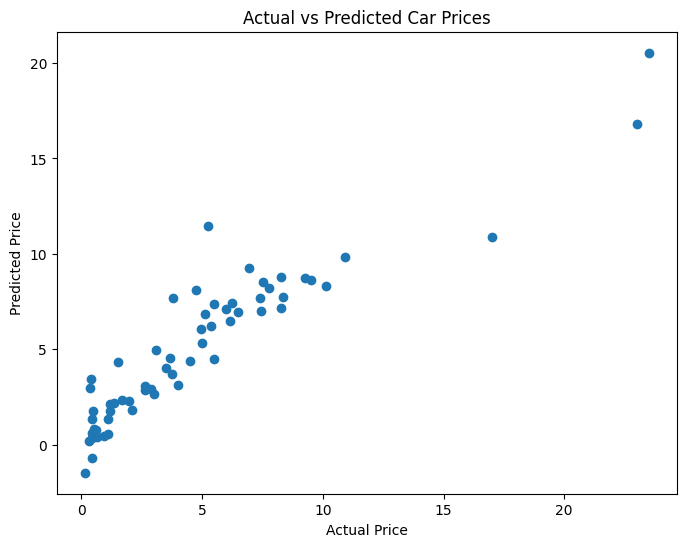

In [15]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()


In [16]:
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=['Coefficient'])

print("\nFeature Importance:")
print(coeff_df)


Feature Importance:
               Coefficient
Present_Price     0.439871
Driven_kms       -0.000005
Fuel_Type        -1.324534
Selling_type     -1.169683
Transmission     -1.637471
Owner            -0.921467
Car_Age          -0.362731


In [17]:

sample_data = [[6.5, 30000, 1, 0, 1, 0, 5]]

predicted_price = model.predict(sample_data)

print("\nPredicted Car Selling Price:")
print(predicted_price[0])


Predicted Car Selling Price:
8.211520277162487


C:\Users\HP\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
